In [1]:
import pennylane as qp
from pennylane import numpy as np

qml = qp

In [2]:
dev = qp.device('default.qubit', wires=4)

@qp.qnode(dev, diff_method='parameter-shift')
def circuit(x, y):
    qp.RX(x[0], wires=0)
    qp.Toffoli(wires=(0, 1, 2))
    qp.CRY(x[1], wires=(0, 1))
    qp.Rot(x[2], x[3], y, wires=0)
    return qp.expval(qp.Z(0)), qp.expval(qp.X(1))

In [4]:
x = np.array([0.05, 0.1, 0.2, 0.3], requires_grad=True)
y = np.array(0.4, requires_grad=False)
specs_func = qp.specs(circuit)
specs_func(x, y)

Device: default.qubit
Device wires: 4
Shots: Shots(total=None)
Level: gradient

Wire allocations: 3
Total gates: 4
Gate counts:
- RX: 1
- Toffoli: 1
- CRY: 1
- Rot: 1
Measurements:
- expval(PauliZ): 1
- expval(PauliX): 1
Depth: 4


In [6]:
dev = qp.device('default.qubit')

@qp.qnode(dev)
def circuit(x, z):
    qp.QFT(wires=(0,1,2,3))
    qp.IsingXX(1.234, wires=(0,2))
    qp.Toffoli(wires=(0,1,2))
    mcm = qp.measure(1)
    mcm_out = qp.measure(2)
    qp.CSWAP(wires=(0,2,3))
    qp.RX(x, wires=0)
    qp.cond(mcm, qp.RY)(np.pi / 4, wires=3)
    qp.CRZ(z, wires=(3,0))
    return qp.expval(qp.Z(0)), qp.probs(op=mcm_out)

print(qp.draw_mpl(circuit))

<function circuit at 0x00000282575E1010>


C:\Users\julia\AppData\Local\Temp\ipykernel_20128\3347251615.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


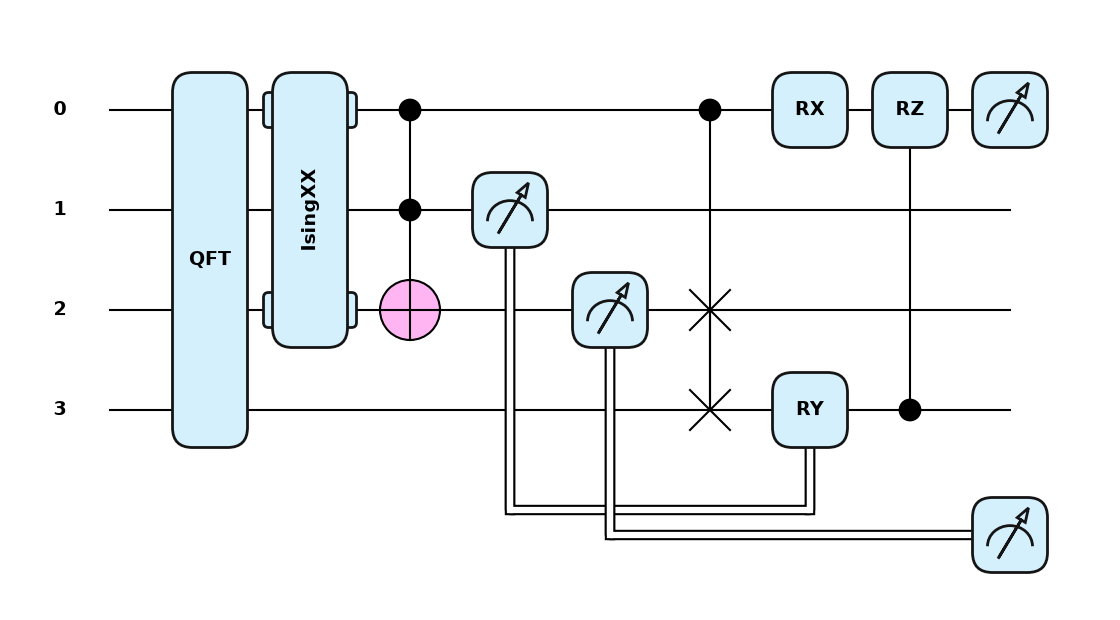

In [7]:
fig, ax = qp.draw_mpl(circuit, style='pennylane')(1.2345,1.2345)
fig.show()

In [8]:
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev, interface=None)
def circuit():
    qp.Snapshot(measurement=qp.expval(qp.Z(0)))
    qp.Hadamard(wires=0)
    qp.Snapshot("very_important_state")
    qp.CNOT(wires=[0, 1])
    qp.Snapshot()
    return qp.expval(qp.X(0))

In [9]:
qp.snapshots(circuit)()

{0: np.float64(1.0),
 'very_important_state': array([ 0.70710678+0.j,  0.        +0.j,  0.70710678+0.j, -0.        +0.j]),
 2: array([ 0.70710678+0.j,  0.        +0.j, -0.        +0.j,  0.70710678+0.j]),
 'execution_results': np.float64(0.0)}